# 📈 Modelo de Crecimiento Logístico con Umbral

## 🧩 Definición del modelo

El modelo combina:
- Saturación (logístico)
- Umbral crítico (efecto Allee)

$$
\frac{dN}{dt} = rN\left(1 - \frac{N}{K}\right)\left(\frac{N}{A} - 1\right)
$$

---

## 📌 Parámetros

- $N(t)$: población  
- $r > 0$: tasa de crecimiento  
- $K$: capacidad de carga  
- $A$: umbral crítico  

---

## ⚙️ Estructura del modelo

Se puede expandir:

$$
\frac{dN}{dt} = rN \left( \frac{N}{A} - 1 \right) \left(1 - \frac{N}{K}\right)
$$

Esto introduce:

- Interacción cuadrática (competencia)
- Umbral (efecto Allee)

---

## 🔧 Solución analítica (forma implícita)

Separación de variables:

$$
\int \frac{dN}{N(1 - N/K)(N/A - 1)} = \int r\,dt
$$

La integral del lado izquierdo requiere fracciones parciales con tres términos:

$$
\frac{1}{N(1 - N/K)(N/A - 1)} =
\frac{A}{N} + \frac{B}{K - N} + \frac{C}{N - A}
$$

Tras integrar:

$$
\ln|N| + \ln|K - N| + \ln|N - A| = rt + C
$$

(la combinación exacta depende de constantes de descomposición)

---

## ⚠️ Nota importante

A diferencia del modelo logístico simple:

👉 No existe una forma cerrada simple como $N(t) = ...$  

La solución es:
- implícita
- o se obtiene numéricamente

---

## ⚖️ Equilibrios

Resolviendo:

$$
rN\left(1 - \frac{N}{K}\right)\left(\frac{N}{A} - 1\right) = 0
$$

Se obtiene:

- $N = 0$  
- $N = A$  
- $N = K$  

---

## 🧠 Estabilidad

- $N = 0$ → estable  
- $N = A$ → inestable (umbral)  
- $N = K$ → estable  

---

## 📊 Interpretación

- $N < A$ → colapso a 0  
- $N > A$ → crecimiento hacia $K$  

---

## 🔥 Insight clave

Este modelo presenta:

👉 **bistabilidad**

- Dos atractores: $0$ y $K$  
- Separados por un umbral crítico $A$

---

## 🌍 Aplicaciones

- Ecología (efecto Allee)  
- Conservación de especies  
- Epidemiología  
- Dinámica social  

---

## ⚠️ Limitaciones

- Determinista  
- Parámetros constantes  
- No incluye ruido ni migración  

---

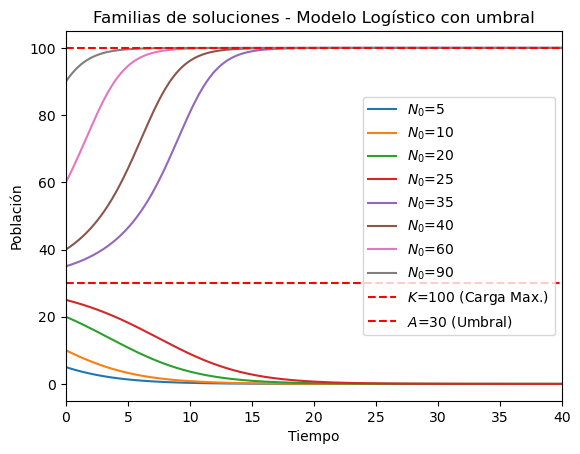

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

def logistic_threshold(N, t, r, K, A):
    return r * N * (1 - N/K) * (N/A - 1)

# Parámetros
r = 0.3
K = 100
A = 30

t = np.linspace(0, 40, 400)

initial_conditions = [5, 10, 20, 25, 35, 40, 60, 90]

plt.figure()

for N0 in initial_conditions:
    N = odeint(logistic_threshold, N0, t, args=(r, K, A))
    plt.plot(t, N, label=f"$N_0$={N0}")

plt.axhline(K, linestyle="--", label=f"$K$={K} (Carga Max.)", color='red')
plt.axhline(A, linestyle="--", label=f"$A$={A} (Umbral)", color='red')

plt.title("Familias de soluciones - Modelo Logístico con umbral")
plt.xlabel("Tiempo")
plt.ylabel("Población")
plt.xlim(0, 40)
plt.legend()
plt.savefig("/Images/familias_soluciones_logistico_umbral.png")
plt.show()

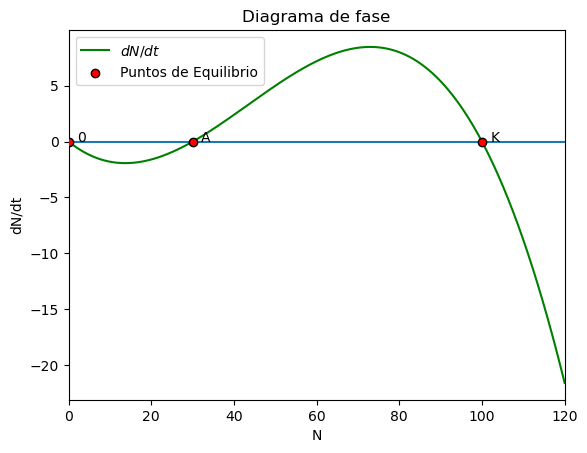

In [ ]:
N = np.linspace(0, 120, 500)
dNdt = r * N * (1 - N/K) * (N/A - 1)

plt.figure()
plt.plot(N, dNdt, color = 'green', label="$dN/dt$")

# Equilibrios
plt.scatter([0, A, K], [0, 0, 0], color = 'red', edgecolors='black', zorder=5, label="Puntos de Equilibrio")
plt.text(2, 0, "0")
plt.text(A+2, 0, "A")
plt.text(K+2, 0, "K")

plt.axhline(0)

plt.xlabel("N")
plt.ylabel("dN/dt")
plt.legend()
plt.title("Diagrama de fase")
plt.xlim(0, 120)
plt.savefig("/Images/diagrama_fase_logistico_umbral.png")
plt.show()